<h1 style="text-align:center;">Projeto Final: Alzheimer's Disease Dataset </h1>



<h2 style="text-align:center;">Pré-Processamento dos Dados</h2>


In [158]:
import pandas as pd

df = pd.read_csv('alzheimers_disease_data.csv')

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.columns = df.columns.map({'PatientID':'ID_Paciente',
                             'Age':'Idade',
                             'Gender':'Genero', #0: masculino; 1: feminino
                             'Ethnicity':'Etnia', #0: Caucasiano; 1: Afro-americano; 2: Asiático; 3: Outro
                             'EducationLevel':'Nivel_Educacao', #0: Nenhum; 1: Ensino Médio; 2: Bacharelado; 3: Ensino Superior
                             'BMI':'IMC',
                             'Smoking':'Fumante', #Categórico
                             'AlcoholConsumption':'Consumo_Alcool',
                             'PhysicalActivity':'Atividade_Fisica',
                             'DietQuality':'Qualidade_Dieta',
                             'SleepQuality':'Qualidade_Sono',
                             'FamilyHistoryAlzheimers':'Historico_Familiar_Alzheimer', #Categórico
                             'CardiovascularDisease':'Doenca_Cardiovascular', #Categórico
                             'Diabetes':'Diabetes', #Categórico
                             'Depression':'Depressao', #Categórico 
                             'HeadInjury':'Traumatismo_Craniano', #Categórico
                             'Hypertension':'Hipertensao', #Categórico
                             'SystolicBP':'Pressao_Sistolica',
                             'DiastolicBP':'Pressao_Diastolica',
                             'CholesterolTotal':'Colesterol_Total',
                             'CholesterolLDL':'Colesterol_LDL',
                             'CholesterolHDL':'Colesterol_HDL',
                             'CholesterolTriglycerides':'Triglicerideos',
                             'MMSE':'MMSE', #Mini Exame do Estado Mental
                             'FunctionalAssessment':'Avaliacao_Funcional',
                             'MemoryComplaints':'Queixas_Memoria', #Categórico
                             'BehavioralProblems':'Problemas_Comportamentais', #Categórico
                             'ADL':'Atividades_Vida_Diaria',
                             'Confusion':'Confusao', #Categórico
                             'Disorientation':'Desorientacao', #Categórico 
                             'PersonalityChanges':'Mudancas_Personalidade', #Categórico
                             'DifficultyCompletingTasks':'Dificuldade_Tarefas', #Categórico
                             'Forgetfulness':'Esquecimento', #Categórico
                             'Diagnosis':'Diagnostico', # classificação
                             'DoctorInCharge':'Medico_Responsavel'
                             })
df.head()

,ID_Paciente,Idade,Genero,Etnia,Nivel_Educacao,IMC,Fumante,Consumo_Alcool,Atividade_Fisica,Qualidade_Dieta,...,Queixas_Memoria,Problemas_Comportamentais,Atividades_Vida_Diaria,Confusao,Desorientacao,Mudancas_Personalidade,Dificuldade_Tarefas,Esquecimento,Diagnostico,Medico_Responsavel
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


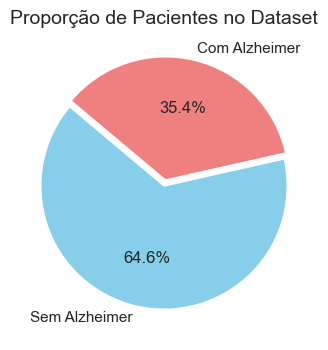

In [159]:
import matplotlib.pyplot as plt

contagem = df['Diagnostico'].value_counts()
labels = ['Sem Alzheimer', 'Com Alzheimer']
cores = ['skyblue', 'lightcoral']

plt.figure(figsize=(4, 4))
plt.pie(contagem, labels=labels, autopct='%1.1f%%', startangle=140, colors=cores, explode=(0, 0.05))
plt.title('Proporção de Pacientes no Dataset', fontsize=14)
plt.show()

<h2 style="text-align:center;">Normalização dos Dados</h2> 

<h3>Removendo Colunas que não são interessantes para a análise.</h3>

In [160]:
import numpy as np

disposable_col = ["ID_Paciente", "Medico_Responsavel"]

df_analise = df.drop(columns=disposable_col)
df_analise.head()

,Idade,Genero,Etnia,Nivel_Educacao,IMC,Fumante,Consumo_Alcool,Atividade_Fisica,Qualidade_Dieta,Qualidade_Sono,...,Avaliacao_Funcional,Queixas_Memoria,Problemas_Comportamentais,Atividades_Vida_Diaria,Confusao,Desorientacao,Mudancas_Personalidade,Dificuldade_Tarefas,Esquecimento,Diagnostico
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


<h3>Normalização dos dados</h3>

In [161]:
colCategoricas = ['Genero', 'Etnia', 'Nivel_Educacao', 'Fumante', 
                  'Historico_Familiar_Alzheimer', 'Doenca_Cardiovascular', 
                  'Diabetes', 'Depressao', 'Traumatismo_Craniano', 'Hipertensao', 
                  'Queixas_Memoria', 'Problemas_Comportamentais', 'Confusao', 'Desorientacao', 
                  'Mudancas_Personalidade', 'Dificuldade_Tarefas', 'Esquecimento', 'Diagnostico']

for col in df_analise.drop(columns=colCategoricas):
    df_analise[col] = (df_analise[col] - df_analise[col].min()) / (df_analise[col].max() - df_analise[col].min())

df_analise.head()

,Idade,Genero,Etnia,Nivel_Educacao,IMC,Fumante,Consumo_Alcool,Atividade_Fisica,Qualidade_Dieta,Qualidade_Sono,...,Avaliacao_Funcional,Queixas_Memoria,Problemas_Comportamentais,Atividades_Vida_Diaria,Confusao,Desorientacao,Mudancas_Personalidade,Dificuldade_Tarefas,Esquecimento,Diagnostico
0,0.433333,0,0,2,0.316960,0,0.665183,0.633375,0.133931,0.837564,...,0.652102,0,0,0.172486,0,0,0,1,0,0
1,0.966667,0,0,0,0.473058,0,0.227170,0.762862,0.050995,0.525021,...,0.712108,0,0,0.259154,0,0,0,0,1,0
2,0.433333,0,3,1,0.111553,0,0.978276,0.785408,0.181896,0.945597,...,0.589697,0,0,0.711936,0,1,0,1,0,0
3,0.466667,1,0,1,0.752163,1,0.610751,0.843804,0.743443,0.731994,...,0.896823,0,1,0.648094,0,0,0,0,0,0
4,0.966667,0,0,0,0.228472,0,0.923204,0.631707,0.078698,0.265892,...,0.604699,0,0,0.001341,0,0,1,1,0,0


<h3>Matriz de Correlação</h3>

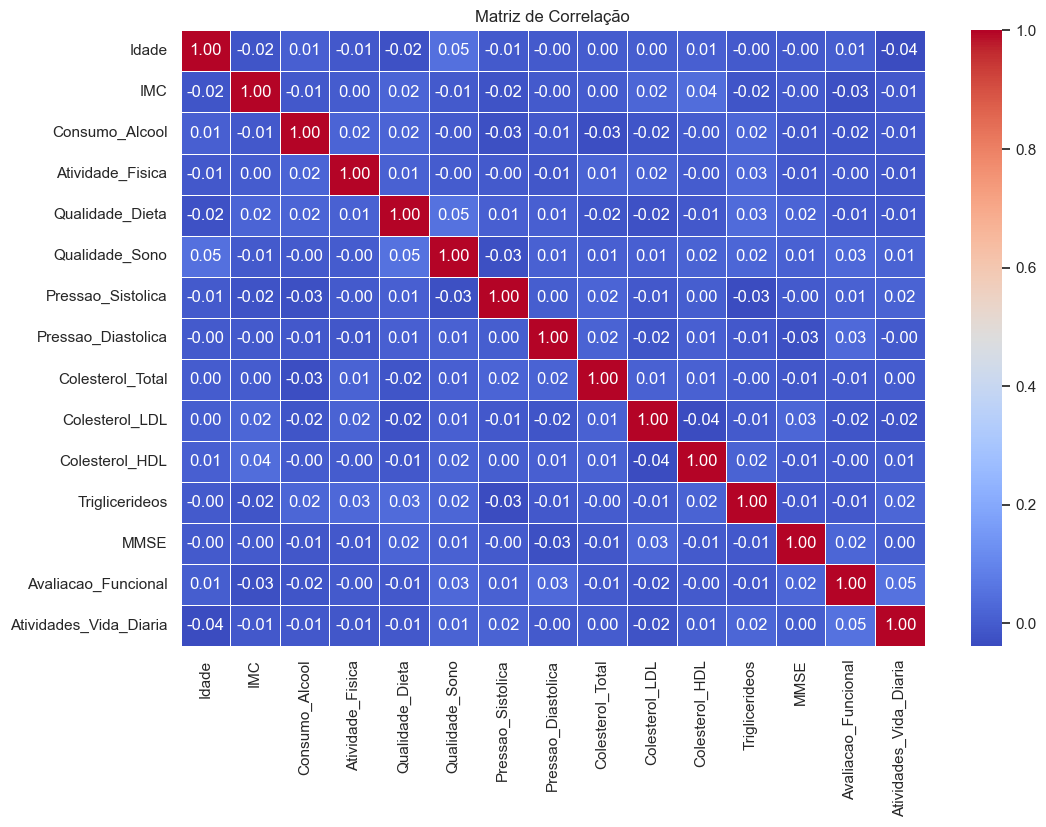

In [162]:
import seaborn as sns

df_corr = df_analise.drop(columns=colCategoricas)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação")
plt.show()

<h3>Cálculo do PCA com <b>Duas</b> Componentes</h3>

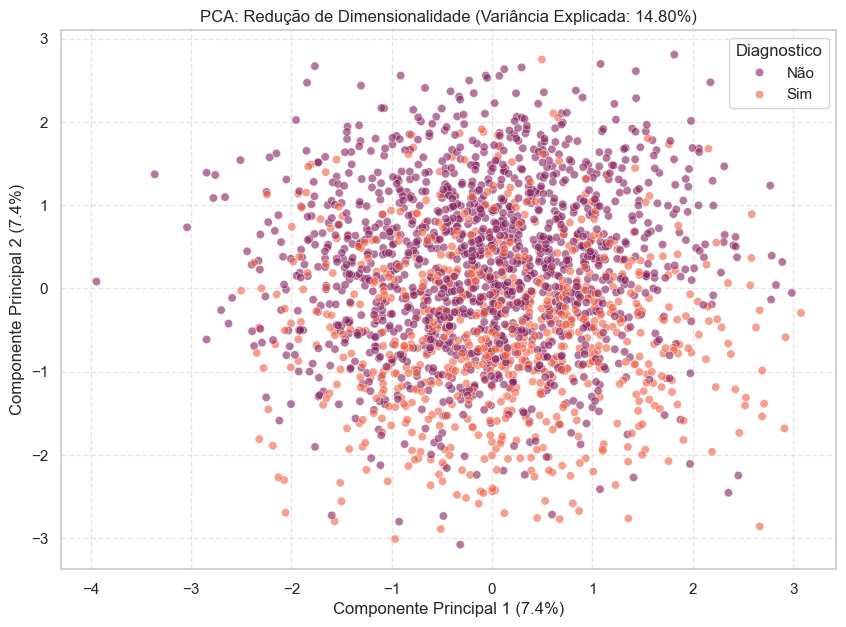

In [163]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_analise.drop(columns=colCategoricas)
y = df_analise['Diagnostico']  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
df_pca['Diagnostico'] = y.map({0: 'Não', 1: 'Sim'}).values

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Diagnostico', data=df_pca, palette='rocket', alpha=0.6)
plt.title(f'PCA: Redução de Dimensionalidade (Variância Explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%)')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<h3>Cálculo do PCA com <b>Três</b> Componentes</h3>

In [164]:
import plotly.express as px

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Label'] = y.map({0: 'Não', 1: 'Sim'})

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Label',
    title=f'PCA 3D (Variância Explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%)',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    }
)

fig.show()

<h2 style="text-align:center">Distribuição de Frequência</h2>

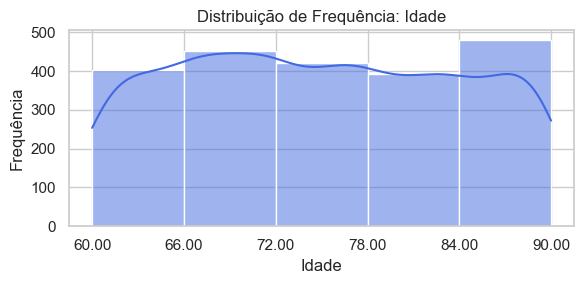

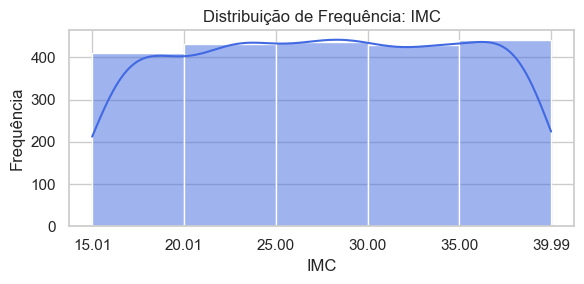

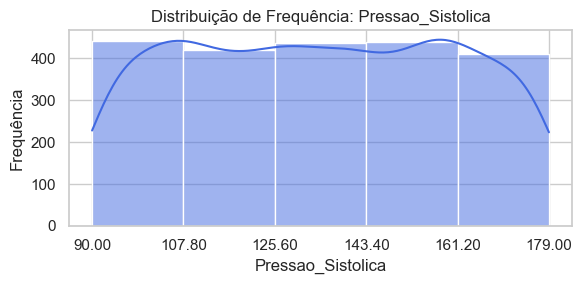

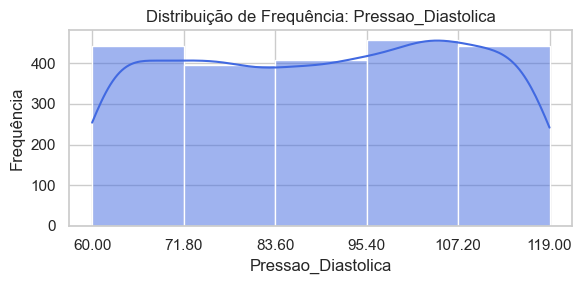

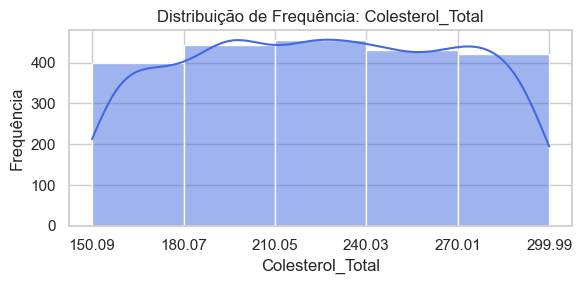

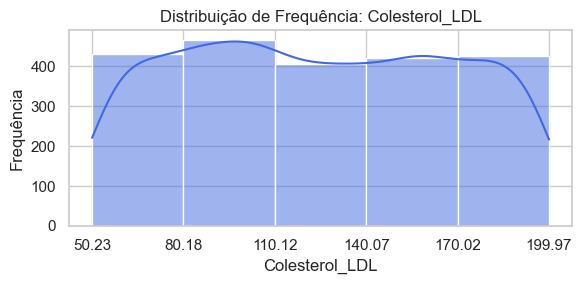

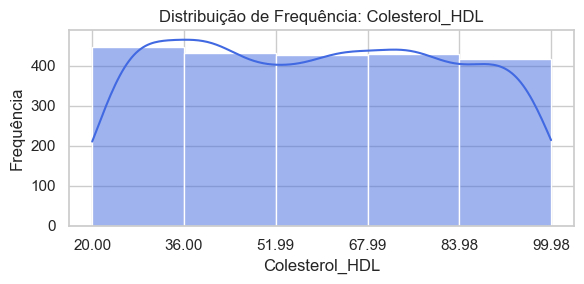

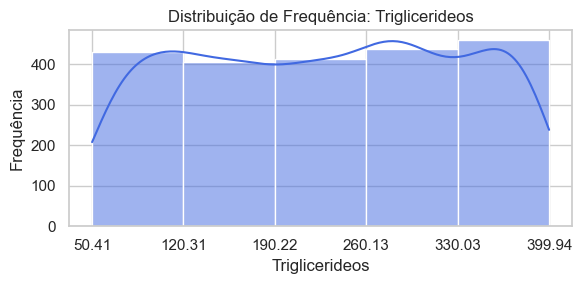

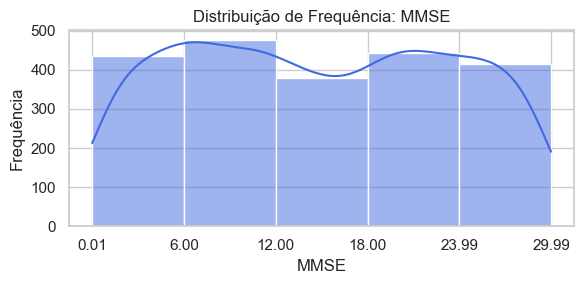

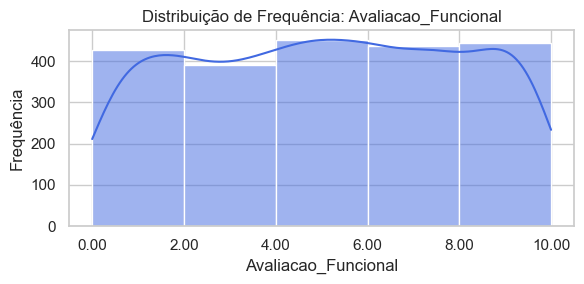

In [165]:
df_medidas = df.drop(columns=disposable_col)

colMedidas = ['Idade', 'IMC', 'Pressao_Sistolica', 'Pressao_Diastolica', 
              'Colesterol_Total', 'Colesterol_LDL', 'Colesterol_HDL', 
              'Triglicerideos', 'MMSE', 'Avaliacao_Funcional']

for col in colMedidas:
    v_min = df_medidas[col].min()
    v_max = df_medidas[col].max()
    
    ticks = np.linspace(v_min, v_max, 6)

    plt.figure(figsize=(6, 3))
    sns.set_theme(style="whitegrid")

    ax = sns.histplot(df_medidas[col], bins=5, kde=True, color='royalblue')
    
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{x:.2f}" for x in ticks])

    plt.title(f'Distribuição de Frequência: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')
    
    plt.tight_layout()
    plt.show()

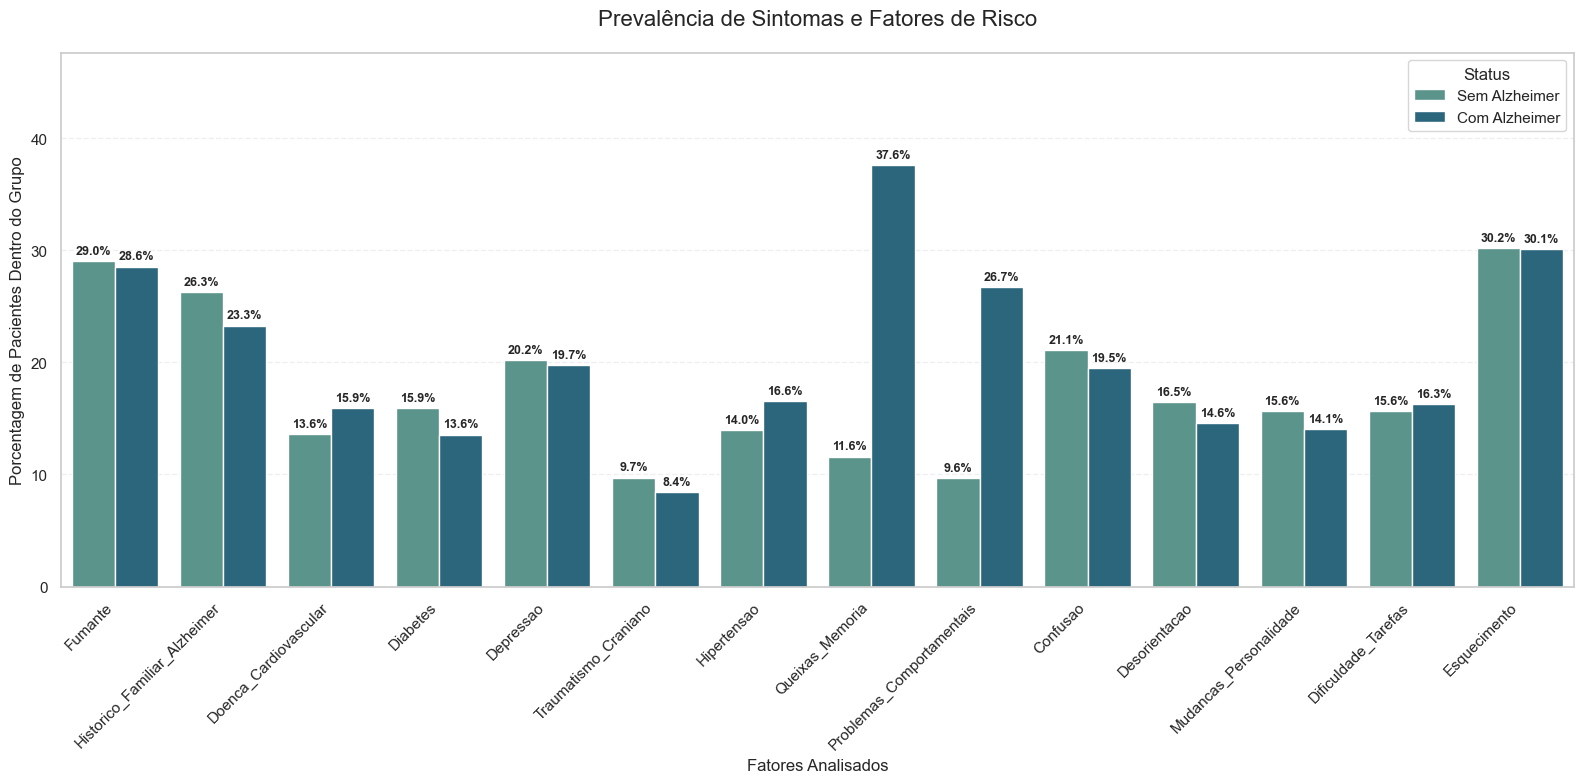

In [166]:
fatores_risco = [
    'Fumante', 'Historico_Familiar_Alzheimer', 'Doenca_Cardiovascular', 'Diabetes',
    'Depressao', 'Traumatismo_Craniano', 'Hipertensao', 'Queixas_Memoria',
    'Problemas_Comportamentais', 'Confusao', 'Desorientacao',
    'Mudancas_Personalidade', 'Dificuldade_Tarefas', 'Esquecimento'
]

dados_percentuais = []
for fator in fatores_risco:
    pcts = df.groupby('Diagnostico')[fator].mean() * 100
    dados_percentuais.append({'Variável': fator, 'Diagnostico': 'Sem Alzheimer', 'Porcentagem': pcts[0]})
    dados_percentuais.append({'Variável': fator, 'Diagnostico': 'Com Alzheimer', 'Porcentagem': pcts[1]})

df_plot = pd.DataFrame(dados_percentuais)
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=df_plot, x='Variável', y='Porcentagem', hue='Diagnostico', palette='crest')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')

plt.title('Prevalência de Sintomas e Fatores de Risco', fontsize=16, pad=20)
plt.ylabel('Porcentagem de Pacientes Dentro do Grupo', fontsize=12)
plt.xlabel('Fatores Analisados', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_plot['Porcentagem'].max() + 10)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<h2 style="text-align:center;">Medidas de Resumo</h2>
<h3>Medidas de Tendência Central</h3>

In [167]:
from IPython.display import display, Markdown

dadosTC = []

for col in colMedidas:
    Min = df_medidas[col].min()
    Max = df_medidas[col].max()
    Media = df_medidas[col].mean()
    Moda = df_medidas[col].mode()[0]
    PontoMedio = (Min + Max) / 2
    Mediana = df_medidas[col].median()

    dadosTC.append({
        'Variável': col,
        'Intervalo': f"{Min:.0f} - {Max:.0f}",
        'Média': Media,
        'Mediana': Mediana,
        'Ponto Médio': PontoMedio,
        'Moda': Moda
    })

tabela = pd.DataFrame(dadosTC)
tabela = tabela.set_index('Variável').round(2)

display(Markdown("### Tabela das Medidas de Tendencia Central dos Dados."))
tabela


### Tabela das Medidas de Tendencia Central dos Dados.

,Intervalo,Média,Mediana,Ponto Médio,Moda
Variável,,,,,
Idade,60 - 90,74.91,75.00,75.00,68.00
IMC,15 - 40,27.66,27.82,27.50,15.01
Pressao_Sistolica,90 - 179,134.26,134.00,134.50,155.00
Pressao_Diastolica,60 - 119,89.85,91.00,89.50,61.00
Colesterol_Total,150 - 300,225.20,225.09,225.04,150.09
Colesterol_LDL,50 - 200,124.34,123.34,125.10,50.23
Colesterol_HDL,20 - 100,59.46,59.77,59.99,20.00
Triglicerideos,50 - 400,228.28,230.30,225.17,50.41
MMSE,0 - 30,14.76,14.44,15.00,0.01


<h3>Medidas de Dispersão</h3>

In [168]:
dadosMD = []

for col in colMedidas:
    Amplitude = df_medidas[col].max() - df_medidas[col].min()
    Desvio = df_medidas[col].std()
    Variancia = Desvio**2
    Coeficiente = Desvio / df_medidas[col].mean()

    dadosMD.append({
        'Variável': col,
        'Amplitude': Amplitude,
        'Desvio Padrão': Desvio,
        'Variância': Variancia,
        'Coeficiente de Variação': f"{Coeficiente:.2%}"
    })

tabela = pd.DataFrame(dadosMD)
tabela = tabela.set_index('Variável').round(2)

display(Markdown("### Tabela das Medidas de Dispersão dos Dados."))
tabela

### Tabela das Medidas de Dispersão dos Dados.

,Amplitude,Desvio Padrão,Variância,Coeficiente de Variação
Variável,,,,
Idade,30.00,8.99,80.82,12.00%
IMC,24.98,7.22,52.09,26.10%
Pressao_Sistolica,89.00,25.95,673.37,19.33%
Pressao_Diastolica,59.00,17.59,309.50,19.58%
Colesterol_Total,149.90,42.54,1809.84,18.89%
Colesterol_LDL,149.73,43.37,1880.66,34.88%
Colesterol_HDL,79.98,23.14,535.42,38.91%
Triglicerideos,349.53,101.99,10401.29,44.68%
MMSE,29.99,8.61,74.19,58.37%


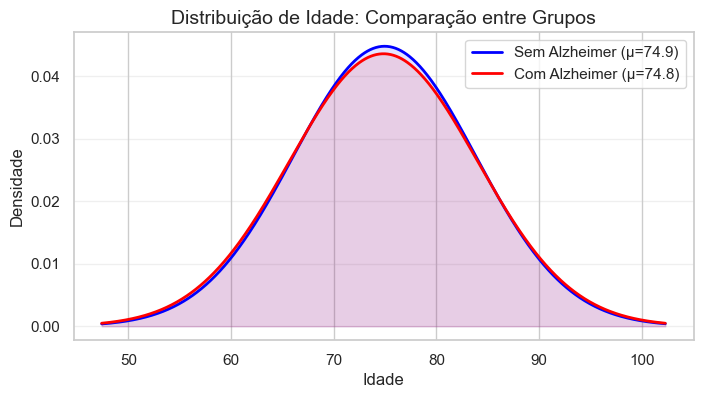

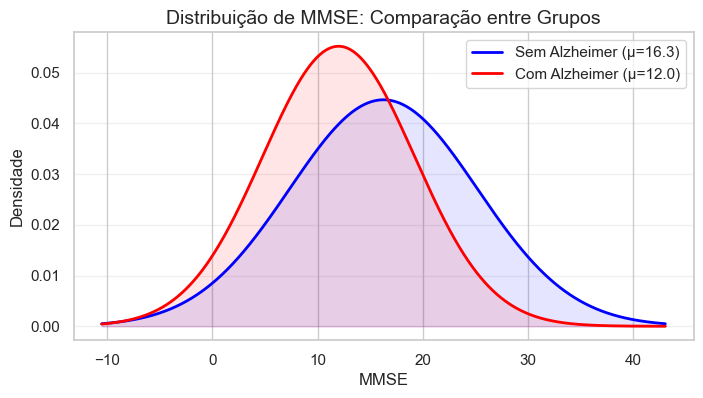

In [169]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

def compararDistribuicao(coluna, df):
    grupoN = df[df['Diagnostico'] == 0][coluna].dropna()
    grupoS = df[df['Diagnostico'] == 1][coluna].dropna()

    muN, stdN = grupoN.mean(), grupoN.std()
    muS, stdS = grupoS.mean(), grupoS.std()

    x = np.linspace(min(muN-3*stdN, muS-3*stdS), max(muN+3*stdN, muS+3*stdS), 1000)

    plt.figure(figsize=(8, 4))
    plt.plot(x, norm.pdf(x, muN, stdN), label=f'Sem Alzheimer (μ={muN:.1f})', color='blue', lw=2)
    plt.fill_between(x, norm.pdf(x, muN, stdN), color='blue', alpha=0.1)

    plt.plot(x, norm.pdf(x, muS, stdS), label=f'Com Alzheimer (μ={muS:.1f})', color='red', lw=2)
    plt.fill_between(x, norm.pdf(x, muS, stdS), color='red', alpha=0.1)

    plt.title(f'Distribuição de {coluna}: Comparação entre Grupos', fontsize=14)
    plt.xlabel(coluna)
    plt.ylabel('Densidade')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
compararDistribuicao('Idade', df)
compararDistribuicao('MMSE', df)

<h3>Medidas de Posição Relativa</h3>

In [170]:
df_zscore = pd.DataFrame()

for col in colMedidas:
    df_zscore[col] = (df_medidas[col] - df_medidas[col].mean()) / df_medidas[col].std()
    df_quantis = np.quantile(df_medidas[col], [0.25,
                                                0.5,
                                                0.75
                                                ])

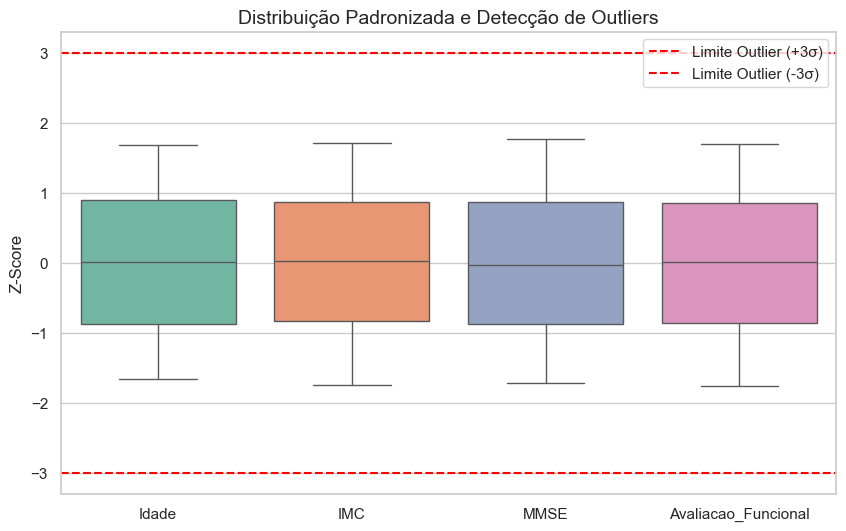

In [171]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_zscore[['Idade', 'IMC', 'MMSE', 'Avaliacao_Funcional']], palette="Set2")
plt.axhline(3, color='red', linestyle='--', label='Limite Outlier (+3σ)')
plt.axhline(-3, color='red', linestyle='--', label='Limite Outlier (-3σ)')
plt.title('Distribuição Padronizada e Detecção de Outliers', fontsize=14)
plt.ylabel('Z-Score')
plt.legend()
plt.show()

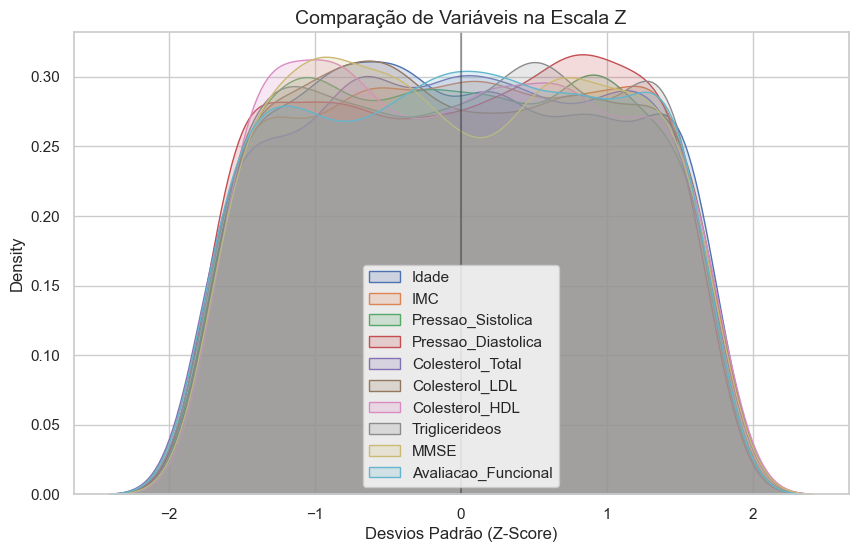

In [172]:
plt.figure(figsize=(10, 6))
for col in colMedidas:
    sns.kdeplot(df_zscore[col], label=col.replace('Z_', ''), fill=True, alpha=0.2)

plt.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.title('Comparação de Variáveis na Escala Z', fontsize=14)
plt.xlabel('Desvios Padrão (Z-Score)')
plt.legend()
plt.show()

<h3>Medidas de Associação</h3>

In [173]:
matriz_cov = df_medidas[colMedidas].cov()

display(Markdown("### Matriz de Covariância"))
display(matriz_cov.round(4))

### Matriz de Covariância

,Idade,IMC,Pressao_Sistolica,Pressao_Diastolica,Colesterol_Total,Colesterol_LDL,Colesterol_HDL,Triglicerideos,MMSE,Avaliacao_Funcional
Idade,80.8241,-1.0172,-1.2421,-0.7057,0.1499,1.3988,1.4152,-2.8075,-0.3279,0.1432
IMC,-1.0172,52.0914,-3.6099,-0.3204,0.3323,7.4130,6.4472,-13.2499,-0.2161,-0.6368
Pressao_Sistolica,-1.2421,-3.6099,673.3689,1.1823,20.4637,-8.2097,1.7695,-92.1625,-0.7931,0.9879
Pressao_Diastolica,-0.7057,-0.3204,1.1823,309.4959,11.4129,-11.8576,3.3301,-14.2248,-4.3315,1.6023
Colesterol_Total,0.1499,0.3323,20.4637,11.4129,1809.8416,19.0684,9.9583,-8.5007,-4.9973,-0.6578
Colesterol_LDL,1.3988,7.4130,-8.2097,-11.8576,19.0684,1880.6606,-37.2769,-24.6884,9.4810,-2.0341
Colesterol_HDL,1.4152,6.4472,1.7695,3.3301,9.9583,-37.2769,535.4214,35.9521,-1.0400,-0.2309
Triglicerideos,-2.8075,-13.2499,-92.1625,-14.2248,-8.5007,-24.6884,35.9521,10401.2912,-6.6889,-2.7162
MMSE,-0.3279,-0.2161,-0.7931,-4.3315,-4.9973,9.4810,-1.0400,-6.6889,74.1864,0.6212
Avaliacao_Funcional,0.1432,-0.6368,0.9879,1.6023,-0.6578,-2.0341,-0.2309,-2.7162,0.6212,8.3680


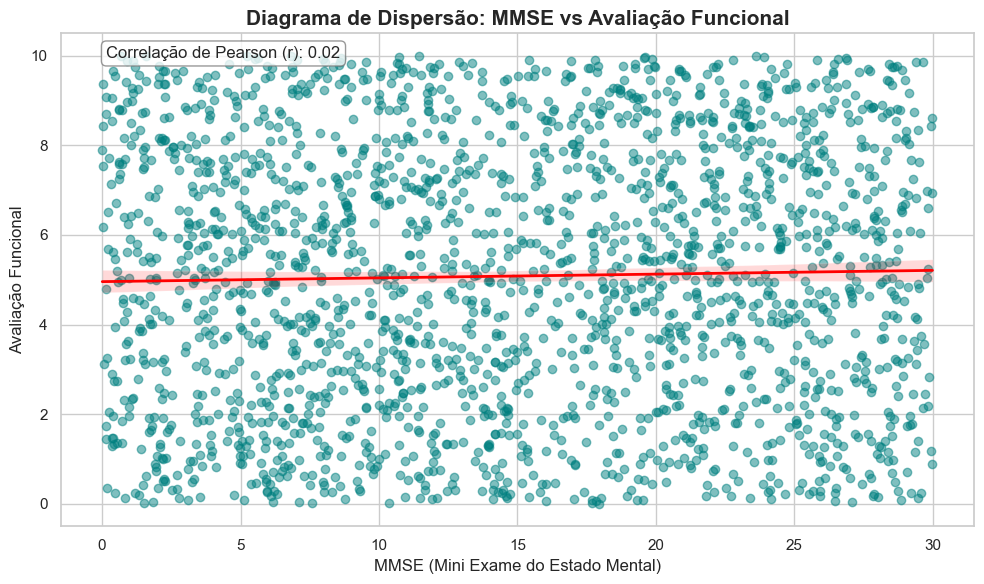

In [174]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(data=df_medidas, x='MMSE', y='Avaliacao_Funcional', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'lw':2})

plt.title('Diagrama de Dispersão: MMSE vs Avaliação Funcional', fontsize=15, fontweight='bold')
plt.xlabel('MMSE (Mini Exame do Estado Mental)')
plt.ylabel('Avaliação Funcional')

r = df['MMSE'].corr(df['Avaliacao_Funcional'])
plt.annotate(f'Correlação de Pearson (r): {r:.2f}', 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.tight_layout()
plt.show()

<h2 style="text-align:center;">Clusterização</h2>
<h3>K-Means</h3>

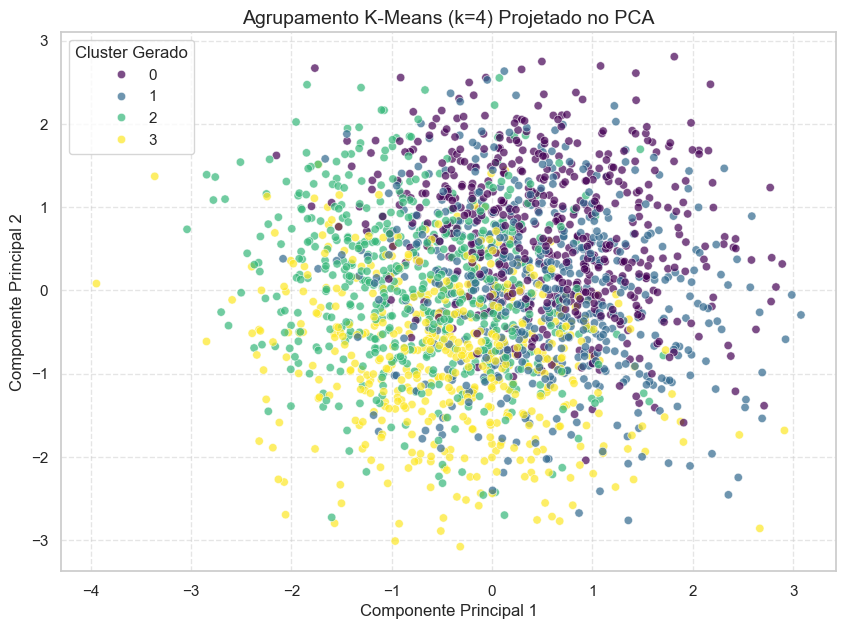

Frequência de Diagnóstico real por Cluster (K-Means):
Diagnostico       0    1
Cluster_KMeans          
0               395  145
1               358  194
2               334  220
3               302  201


In [175]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

df_pca['Cluster_KMeans'] = labels_kmeans

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_KMeans', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Agrupamento K-Means (k=4) Projetado no PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster Gerado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Frequência de Diagnóstico real por Cluster (K-Means):")
print(pd.crosstab(df_pca['Cluster_KMeans'], y))

<h3>GMM</h3>

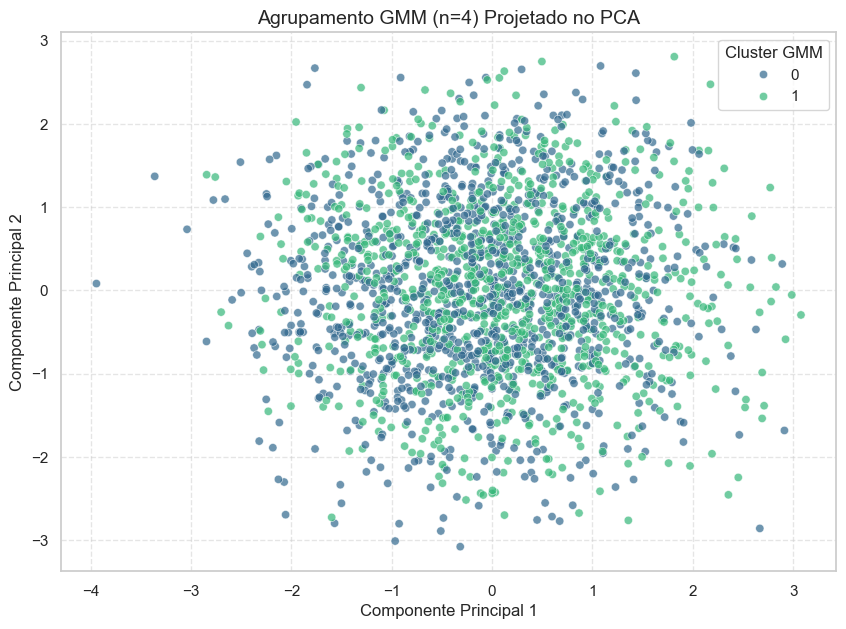

Frequência de Diagnóstico real por Cluster (GMM):
Diagnostico    0    1
Cluster_GMM          
0            724  402
1            665  358


In [176]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

df_pca['Cluster_GMM'] = labels_gmm

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_GMM', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Agrupamento GMM (n=4) Projetado no PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster GMM')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Frequência de Diagnóstico real por Cluster (GMM):")
print(pd.crosstab(df_pca['Cluster_GMM'], y))

<h2 style="text-align:center;">Exemplo KNN Python (Implementação Manual)</h2>

In [177]:
from math import sqrt

def cal_dist_euclideana(vet1,vet2):
    distancia = 0
    for i in range(len(vet1)-1):
        distancia += (vet1[i]-vet2[i])**2
    distancia = sqrt(distancia)
    return distancia

def retorna_vizinhos(base_treinamento, amostra_teste, k): #base_tre = base de treinamento em forma de matriz; amo_teste = amostra de teste; k = k vizinhos
    distancia = list()
    for amostra_treinamento in base_treinamento:
        dist = cal_dist_euclideana(amostra_treinamento, amostra_teste)
        distancia.append((amostra_treinamento,dist))
    #ordenação pela distancia de forma crescente
    distancia.sort(key=lambda tup:tup[1])
    vizinhos = list()
    for i in range(k):
        vizinhos.append(distancia[i][0])
    return vizinhos

def classifica(base_treinamento, amostra_teste, k):
    vizinhos = retorna_vizinhos(base_treinamento, amostra_teste, k)
    rotulos = [v[-1] for v in vizinhos]
    predicao = max(set(rotulos), key=rotulos.count)
    return predicao

dataset = [[2.7,2.5,0],[1.4,2.3,0],[3.3,4.4,0],[1.3,1.8,0],[3,3,0],[7.6,2.7,1],[5.3,2,1],[6.9,1.7,1],[8.6,-0.2,1],[7.6,5,1]]
amostra = [0,0,0]

predicao = classifica(dataset,amostra,3)
print('Resultado classificação')
print('Esperado %d\nPredicao %d'%(amostra[-1],predicao))

Resultado classificação
Esperado 0
Predicao 0


<h2 style="text-align:center;">Classificação</h2>

Foram testados seis classificadores para prever o diagnóstico, usando as variáveis contínuas e categóricas do dataset. Cada modelo é apresentado individualmente, com suas métricas Holdout (70/30) e Validação Cruzada (10 folds), Matriz de Confusão, Acurácia e F1-Score. Ao final, uma comparação geral.

<h3>Variáveis e Divisão Holdout (70/30)</h3>

In [178]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Todas as variáveis (contínuas em min-max + categóricas), exceto o alvo
X_full = df_analise.drop(columns=['Diagnostico'])
y_full = df_analise['Diagnostico']
X_full_scaled = StandardScaler().fit_transform(X_full)
print(f"Variáveis usadas: {X_full.shape[1]}")

modelos_full = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Rede Neural (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                                       alpha=1e-4, batch_size=32, learning_rate_init=1e-3,
                                       max_iter=500, early_stopping=True, n_iter_no_change=15, random_state=42),
}

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full_scaled, y_full, test_size=0.3, random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Variáveis usadas: 32


<h3>KNN (k=5)</h3>

Acurácia (Holdout):    0.7132
Acurácia (CV 10-fold): 0.7175 ± 0.0169
F1-Score (Holdout):    0.5387

               precision    recall  f1-score   support

Sem Alzheimer       0.72      0.88      0.79       401
Com Alzheimer       0.69      0.44      0.54       244

     accuracy                           0.71       645
    macro avg       0.70      0.66      0.67       645
 weighted avg       0.71      0.71      0.70       645



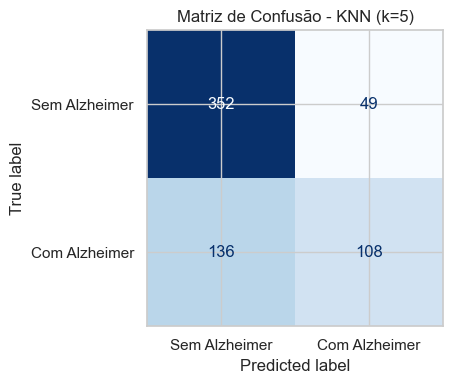

In [179]:
nome = 'KNN (k=5)'
modelo = modelos_full[nome]
modelo.fit(X_train_f, y_train_f)
y_pred = modelo.predict(X_test_f)
scores = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')

print(f"Acurácia (Holdout):    {accuracy_score(y_test_f, y_pred):.4f}")
print(f"Acurácia (CV 10-fold): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1-Score (Holdout):    {f1_score(y_test_f, y_pred):.4f}\n")
print(classification_report(y_test_f, y_pred, target_names=['Sem Alzheimer', 'Com Alzheimer']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_f, y_pred),
                       display_labels=['Sem Alzheimer', 'Com Alzheimer']).plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)
plt.tight_layout()
plt.show()

<h3>SVM (RBF)</h3>

Acurácia (Holdout):    0.8109
Acurácia (CV 10-fold): 0.8455 ± 0.0179
F1-Score (Holdout):    0.7265

               precision    recall  f1-score   support

Sem Alzheimer       0.81      0.90      0.86       401
Com Alzheimer       0.80      0.66      0.73       244

     accuracy                           0.81       645
    macro avg       0.81      0.78      0.79       645
 weighted avg       0.81      0.81      0.81       645



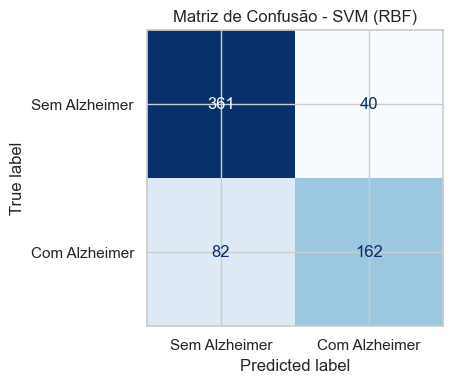

In [180]:
nome = 'SVM (RBF)'
modelo = modelos_full[nome]
modelo.fit(X_train_f, y_train_f)
y_pred = modelo.predict(X_test_f)
scores = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')

print(f"Acurácia (Holdout):    {accuracy_score(y_test_f, y_pred):.4f}")
print(f"Acurácia (CV 10-fold): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1-Score (Holdout):    {f1_score(y_test_f, y_pred):.4f}\n")
print(classification_report(y_test_f, y_pred, target_names=['Sem Alzheimer', 'Com Alzheimer']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_f, y_pred),
                       display_labels=['Sem Alzheimer', 'Com Alzheimer']).plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Árvore de Decisão</h3>

Acurácia (Holdout):    0.8775
Acurácia (CV 10-fold): 0.8939 ± 0.0084
F1-Score (Holdout):    0.8351

               precision    recall  f1-score   support

Sem Alzheimer       0.89      0.91      0.90       401
Com Alzheimer       0.85      0.82      0.84       244

     accuracy                           0.88       645
    macro avg       0.87      0.87      0.87       645
 weighted avg       0.88      0.88      0.88       645



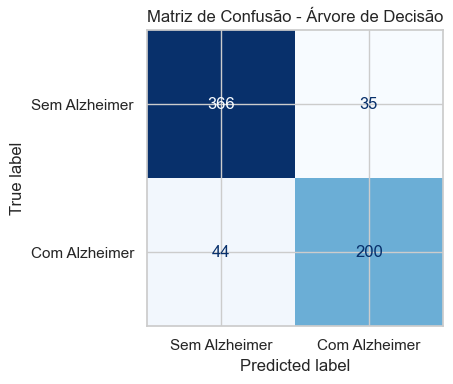

In [181]:
nome = 'Árvore de Decisão'
modelo = modelos_full[nome]
modelo.fit(X_train_f, y_train_f)
y_pred = modelo.predict(X_test_f)
scores = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')

print(f"Acurácia (Holdout):    {accuracy_score(y_test_f, y_pred):.4f}")
print(f"Acurácia (CV 10-fold): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1-Score (Holdout):    {f1_score(y_test_f, y_pred):.4f}\n")
print(classification_report(y_test_f, y_pred, target_names=['Sem Alzheimer', 'Com Alzheimer']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_f, y_pred),
                       display_labels=['Sem Alzheimer', 'Com Alzheimer']).plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Random Forest</h3>

Acurácia (Holdout):    0.9054
Acurácia (CV 10-fold): 0.9423 ± 0.0104
F1-Score (Holdout):    0.8635

               precision    recall  f1-score   support

Sem Alzheimer       0.88      0.98      0.93       401
Com Alzheimer       0.95      0.79      0.86       244

     accuracy                           0.91       645
    macro avg       0.92      0.88      0.90       645
 weighted avg       0.91      0.91      0.90       645



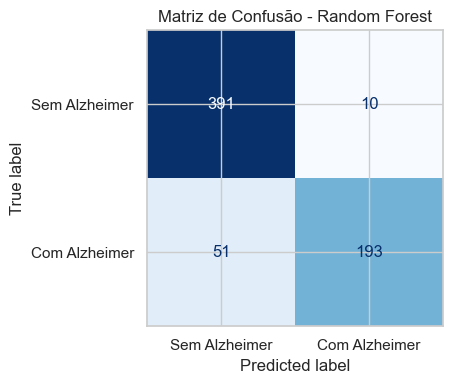

In [182]:
nome = 'Random Forest'
modelo = modelos_full[nome]
modelo.fit(X_train_f, y_train_f)
y_pred = modelo.predict(X_test_f)
scores = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')

print(f"Acurácia (Holdout):    {accuracy_score(y_test_f, y_pred):.4f}")
print(f"Acurácia (CV 10-fold): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1-Score (Holdout):    {f1_score(y_test_f, y_pred):.4f}\n")
print(classification_report(y_test_f, y_pred, target_names=['Sem Alzheimer', 'Com Alzheimer']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_f, y_pred),
                       display_labels=['Sem Alzheimer', 'Com Alzheimer']).plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Regressão Logística</h3>

Acurácia (Holdout):    0.8155
Acurácia (CV 10-fold): 0.8348 ± 0.0234
F1-Score (Holdout):    0.7419

               precision    recall  f1-score   support

Sem Alzheimer       0.83      0.89      0.86       401
Com Alzheimer       0.79      0.70      0.74       244

     accuracy                           0.82       645
    macro avg       0.81      0.79      0.80       645
 weighted avg       0.81      0.82      0.81       645



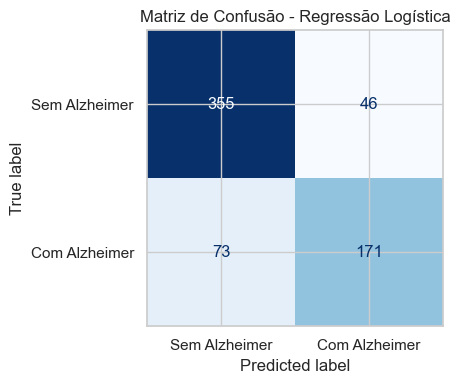

In [183]:
nome = 'Regressão Logística'
modelo = modelos_full[nome]
modelo.fit(X_train_f, y_train_f)
y_pred = modelo.predict(X_test_f)
scores = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')

print(f"Acurácia (Holdout):    {accuracy_score(y_test_f, y_pred):.4f}")
print(f"Acurácia (CV 10-fold): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1-Score (Holdout):    {f1_score(y_test_f, y_pred):.4f}\n")
print(classification_report(y_test_f, y_pred, target_names=['Sem Alzheimer', 'Com Alzheimer']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_f, y_pred),
                       display_labels=['Sem Alzheimer', 'Com Alzheimer']).plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Rede Neural (MLP)</h3>

Acurácia (Holdout):    0.7907
Acurácia (CV 10-fold): 0.8283 ± 0.0157
F1-Score (Holdout):    0.6993

               precision    recall  f1-score   support

Sem Alzheimer       0.80      0.88      0.84       401
Com Alzheimer       0.77      0.64      0.70       244

     accuracy                           0.79       645
    macro avg       0.78      0.76      0.77       645
 weighted avg       0.79      0.79      0.79       645



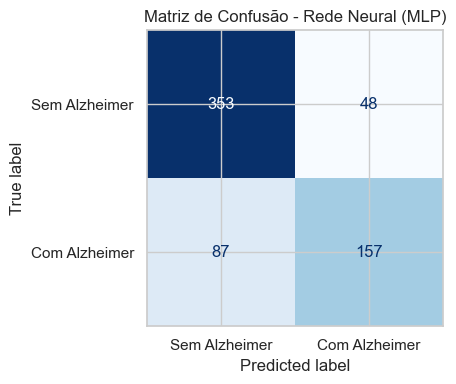

In [184]:
nome = 'Rede Neural (MLP)'
modelo = modelos_full[nome]
modelo.fit(X_train_f, y_train_f)
y_pred = modelo.predict(X_test_f)
scores = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')

print(f"Acurácia (Holdout):    {accuracy_score(y_test_f, y_pred):.4f}")
print(f"Acurácia (CV 10-fold): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"F1-Score (Holdout):    {f1_score(y_test_f, y_pred):.4f}\n")
print(classification_report(y_test_f, y_pred, target_names=['Sem Alzheimer', 'Com Alzheimer']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_f, y_pred),
                       display_labels=['Sem Alzheimer', 'Com Alzheimer']).plot(cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Comparação Geral dos Modelos</h3>

In [185]:
from sklearn.metrics import accuracy_score, f1_score

preds_full = {}
resultados_full = []
for nome, modelo in modelos_full.items():
    modelo.fit(X_train_f, y_train_f)
    y_p = modelo.predict(X_test_f)
    preds_full[nome] = y_p
    sc = cross_val_score(modelo, X_full_scaled, y_full, cv=cv, scoring='accuracy')
    resultados_full.append({
        'Classificador': nome,
        'Acurácia (Holdout)': accuracy_score(y_test_f, y_p),
        'F1 Score (Holdout)': f1_score(y_test_f, y_p),
        'Acurácia Média (CV 10-Fold)': sc.mean(),
        'Desvio Padrão (CV)': sc.std(),
    })

df_full = pd.DataFrame(resultados_full).set_index('Classificador')
df_full = df_full.sort_values('Acurácia Média (CV 10-Fold)', ascending=False).round(4)
display(Markdown('### Desempenho com todas as variáveis (contínuas + categóricas)'))
display(df_full)

### Desempenho com todas as variáveis (contínuas + categóricas)

,Acurácia (Holdout),F1 Score (Holdout),Acurácia Média (CV 10-Fold),Desvio Padrão (CV)
Classificador,,,,
Random Forest,0.9054,0.8635,0.9423,0.0104
Árvore de Decisão,0.8775,0.8351,0.8939,0.0084
SVM (RBF),0.8109,0.7265,0.8455,0.0179
Regressão Logística,0.8155,0.7419,0.8348,0.0234
Rede Neural (MLP),0.7907,0.6993,0.8283,0.0157
KNN (k=5),0.7132,0.5387,0.7175,0.0169


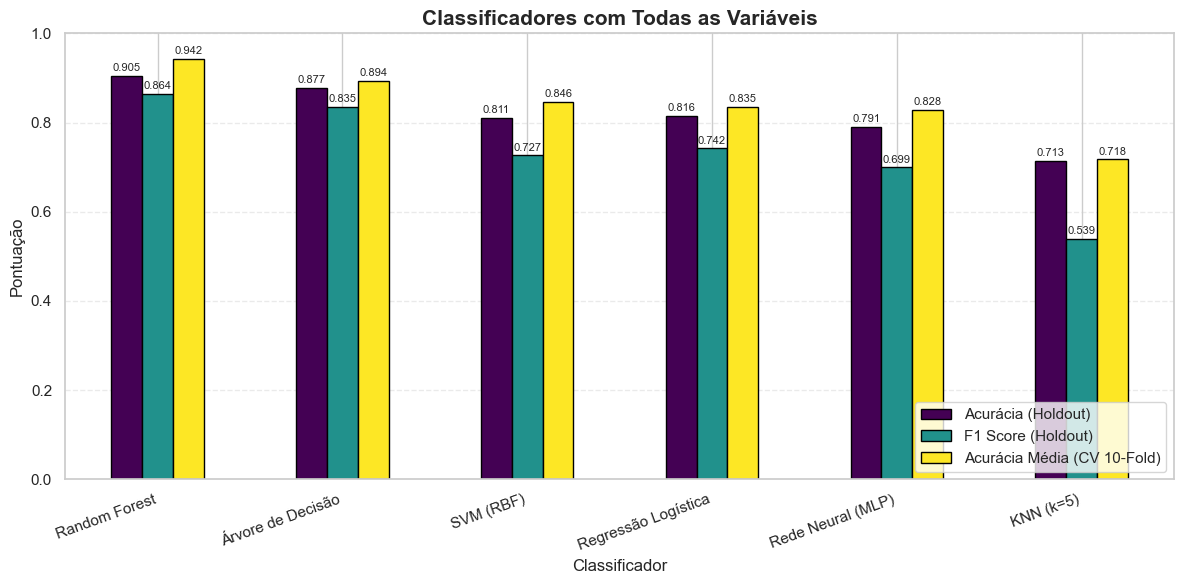

In [186]:
ax = df_full[['Acurácia (Holdout)', 'F1 Score (Holdout)', 'Acurácia Média (CV 10-Fold)']].plot(
    kind='bar', figsize=(12, 6), edgecolor='black', colormap='viridis')

plt.title('Classificadores com Todas as Variáveis', fontsize=15, fontweight='bold')
plt.ylabel('Pontuação')
plt.xlabel('Classificador')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

<h3>Conclusão</h3>

O desempenho dos modelos, com destaque para os baseados em árvores:

| Classificador | Acurácia (Holdout) | F1 (Holdout) | Acurácia Média (CV) | Desvio (CV) |
|---|---|---|---|---|
| **Random Forest** | **0.9054** | **0.8635** | **0.9423** | 0.0104 |
| Árvore de Decisão | 0.8775 | 0.8351 | 0.8939 | **0.0084** |
| SVM (RBF) | 0.8109 | 0.7265 | 0.8455 | 0.0179 |
| Regressão Logística | 0.8155 | 0.7419 | 0.8348 | 0.0234 |
| Rede Neural (MLP) | 0.7907 | 0.6993 | 0.8283 | 0.0157 |
| KNN (k=5) | 0.7132 | 0.5387 | 0.7175 | 0.0169 |


<h2 style="text-align:center;">Teste: Base Balanceada (50/50)</h2>

Teste com a base **balanceada em 50/50** entre as classes (por *undersampling* da classe majoritária), treinando o **Random Forest** com todas as variáveis. É a configuração usada nos trabalhos publicados com este dataset (Random Forest ≈ 94,9%).

<h3>Balanceamento (50/50)</h3>

In [187]:
from sklearn.utils import resample

# Balanceia df_analise (todas as variáveis) em 50/50 por undersampling
df_maj_f = df_analise[df_analise['Diagnostico'] == 0]
df_min_f = df_analise[df_analise['Diagnostico'] == 1]
df_maj_f_under = resample(df_maj_f, replace=False, n_samples=len(df_min_f), random_state=42)
df_bal_full = pd.concat([df_maj_f_under, df_min_f]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Distribuição balanceada (50/50):')
print(df_bal_full['Diagnostico'].value_counts())

# Todas as variáveis (contínuas + categóricas), exceto o alvo
X_fb = df_bal_full.drop(columns=['Diagnostico'])
y_fb = df_bal_full['Diagnostico']
X_fb_scaled = StandardScaler().fit_transform(X_fb)
print(f'\nVariáveis usadas: {X_fb.shape[1]}')

Distribuição balanceada (50/50):
Diagnostico
0    760
1    760
Name: count, dtype: int64

Variáveis usadas: 32


<h3>Holdout (70% Treino / 30% Teste)</h3>

In [188]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train_fb, X_test_fb, y_train_fb, y_test_fb = train_test_split(
    X_fb_scaled, y_fb, test_size=0.3, random_state=42, stratify=y_fb)

rf_fb = RandomForestClassifier(random_state=42)
rf_fb.fit(X_train_fb, y_train_fb)
y_pred_fb = rf_fb.predict(X_test_fb)

print(f"Amostras de Treinamento: {X_train_fb.shape[0]} | Amostras de Teste: {X_test_fb.shape[0]}")
print(f"Acurácia no conjunto de teste: {rf_fb.score(X_test_fb, y_test_fb):.4f}")

Amostras de Treinamento: 1064 | Amostras de Teste: 456
Acurácia no conjunto de teste: 0.9430


<h3>Validação Cruzada (k=10)</h3>

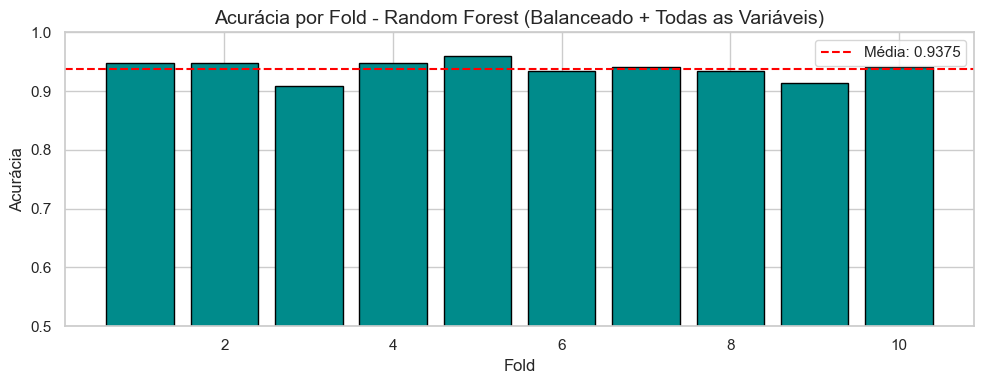

Média: 0.9375 | Desvio Padrão: 0.0151


In [189]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores_fb = cross_val_score(RandomForestClassifier(random_state=42), X_fb_scaled, y_fb, cv=cv, scoring='accuracy')

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), scores_fb, color='darkcyan', edgecolor='black')
plt.axhline(scores_fb.mean(), color='red', linestyle='--', label=f'Média: {scores_fb.mean():.4f}')
plt.title('Acurácia por Fold - Random Forest (Balanceado + Todas as Variáveis)', fontsize=14)
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Média: {scores_fb.mean():.4f} | Desvio Padrão: {scores_fb.std():.4f}")

<h3>Matriz de Confusão</h3>

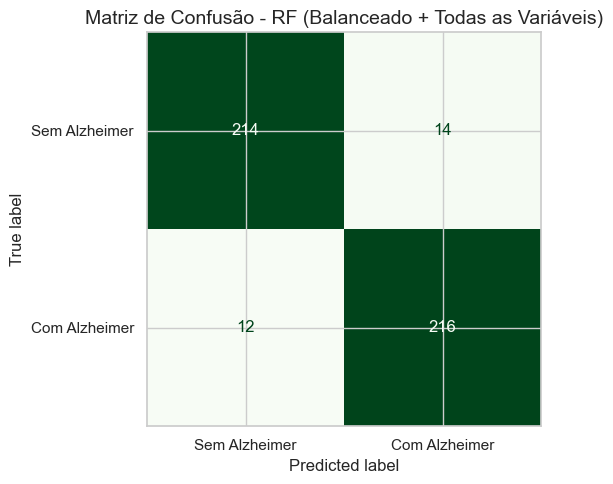

In [190]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_fb = confusion_matrix(y_test_fb, y_pred_fb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fb, display_labels=['Sem Alzheimer', 'Com Alzheimer'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Greens', colorbar=False, ax=ax)
plt.title('Matriz de Confusão - RF (Balanceado + Todas as Variáveis)', fontsize=14)
plt.tight_layout()
plt.show()

<h3>Métricas</h3>

In [191]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc_fb = accuracy_score(y_test_fb, y_pred_fb)
f1_fb = f1_score(y_test_fb, y_pred_fb)
print(f"Acurácia: {acc_fb:.4f} ({acc_fb*100:.2f}%)")
print(f"F1 Score: {f1_fb:.4f}")
print("Relatório Completo:")
print(classification_report(y_test_fb, y_pred_fb, target_names=['Sem Alzheimer', 'Com Alzheimer']))

Acurácia: 0.9430 (94.30%)
F1 Score: 0.9432
Relatório Completo:
               precision    recall  f1-score   support

Sem Alzheimer       0.95      0.94      0.94       228
Com Alzheimer       0.94      0.95      0.94       228

     accuracy                           0.94       456
    macro avg       0.94      0.94      0.94       456
 weighted avg       0.94      0.94      0.94       456



<h3>Conclusão do Teste</h3>

Balanceando a base em **50/50**, o Random Forest atinge seu melhor resultado, equilibrado entre as duas classes:

| Cenário (Random Forest) | Acurácia (teste) | F1 | Revocação (Com) | CV (10) |
|---|---|---|---|---|
| Base original | 0,905 | 0,86 | 0,79 | 0,942 |
| balanceado (50/50) | **0,943** | **0,94** | **0,95** | 0,938 |


<h2 style="text-align:center;">Conclusão</h2>

<p style="text-align: justify;">O presente trabalho desenvolveu o fluxo completo de análise de dados sobre o Alzheimer's Disease Dataset, composto por 2.149 pacientes, contemplando o pré-processamento, a normalização, a redução de dimensionalidade, a estatística descritiva, a clusterização e a classificação supervisionada. A etapa exploratória evidenciou uma base íntegra e bem comportada cujas variáveis apresentaram distribuições aproximadamente simétricas e baixa associação linear entre si, com destaque para a independência observada entre o MMSE e a Avaliação Funcional (coeficiente de Pearson ≈ 0,02). A ausência de estrutura natural de agrupamento, confirmada pelo baixo coeficiente de silhueta (≈ 0,05) e pela reduzida variância explicada pelos dois primeiros componentes principais (≈ 15%), indicou que a separação relevante dos dados está associada ao próprio diagnóstico, e não a agrupamentos espontâneos. Na fase supervisionada, seis classificadores foram comparados sob validação por holdout (70/30) e validação cruzada estratificada (10 folds), utilizando o conjunto completo de variáveis (contínuas e categóricas), sendo o Random Forest o modelo de melhor desempenho e maior estabilidade, com acurácia de 90,5%, F1-score de 0,86 e acurácia média de 94,2% (desvio padrão de 1,0%) na validação cruzada, superando tanto os modelos lineares e baseados em distância quanto a rede neural, resultado coerente com a natureza tabular dos dados. A análise de importância das variáveis revelou que os indicadores funcionais e cognitivos (Avaliação Funcional, ADL e MMSE) concentram aproximadamente 47% do poder preditivo, complementados pelos sintomas relatados, como as Queixas de Memória, sobrepondo-se aos exames laboratoriais. Conclui-se, portanto, que é viável prever o diagnóstico de Alzheimer com acurácia próxima a 94% a partir de variáveis clínicas, recomendando-se o Random Forest como modelo preferencial; ressalta-se que, na base original (desbalanceada, com cerca de 35% de casos positivos), a revocação da classe positiva foi de 79,1%, e que o balanceamento das classes em 50/50, avaliado experimentalmente, elevou-a a 94,7%, reduzindo os falsos negativos e aprimorando a identificação dos pacientes acometidos.</p>